In [4]:
import numpy as np
from sklearn import linear_model  # scikit-learn 모듈을 가져온다

regr = linear_model.LinearRegression()

In [5]:
X = [[163], [179], [166], [169], [170]]
y = [54, 63, 57, 56, 58]
regr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


행렬값이어야 하기 때문에 대괄호를 하나 더 쳐 주었다.

In [22]:
coef=regr.coef_
coef
intercept=regr.intercept_
intercept
regr.predict([[178]])
regr.score(X,y)


0.9222616348521422

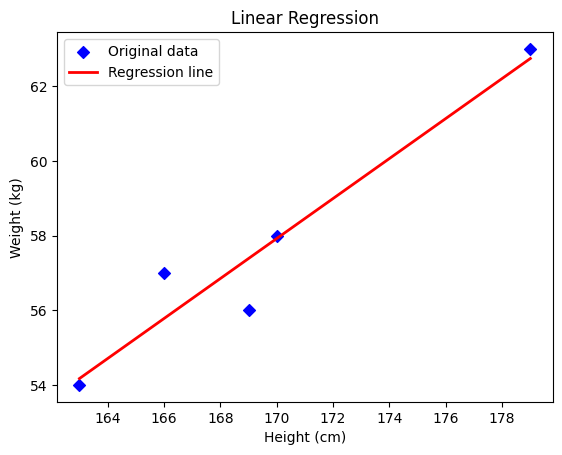

In [24]:
import matplotlib.pyplot as plt

# 원본 데이터를 산점도로 표시
plt.scatter(X, y, color='blue', marker='D', label='Original data')

# 회귀선 그리기
X_test = np.linspace(163, 179, 100).reshape(-1, 1)
y_pred = regr.predict(X_test)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.title('Linear Regression')
plt.show()

TypeError: object of type 'numpy._ArrayFunctionDispatcher' has no len()

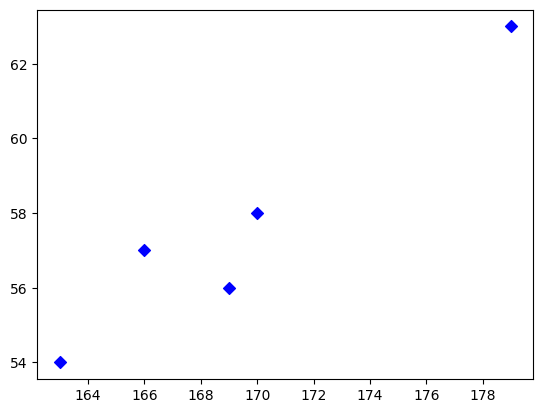

In [25]:

import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', marker='D', label='Original data')

weight=0.5
b=-33

x= np.linspace(169, 180, 100)
y= weight * x+b

plt.plot(np,y)

In [26]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
# 남자는 0, 여자는 1
X = [[168, 0], [166, 0], [173, 0], [165, 0], [177, 0], [163, 0], \
     [178, 0], [172, 0], [163, 1], [162, 1], [171, 1], [162, 1], \
     [164, 1], [162, 1], [158, 1], [173, 1], ]    # 입력데이터를 2차원으로 만들어야 함
# y 값은 1차원 데이터
y = [65, 61, 68, 63, 68, 61, 76, 67, 55, 51, 59, 53, 61, 56, 44, 57]
regr.fit(X, y)         # 학습
print('계수 :', regr.coef_ )
print('절편 :', regr.intercept_)
print('점수 :', regr.score(X, y))
print('동윤이와 은지의 추정 몸무게 :', regr.predict([[167, 0], [167, 1]]))

계수 : [ 0.74803397 -7.23030041]
절편 : -61.22778389430634
점수 : 0.8425933302504423
동윤이와 은지의 추정 몸무게 : [63.69388959 56.46358918]


/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47800 (\N{HANGUL SYLLABLE MOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/robot/work/Robot-AI/deeplearning/.venv/lib/python3.12/site-packag

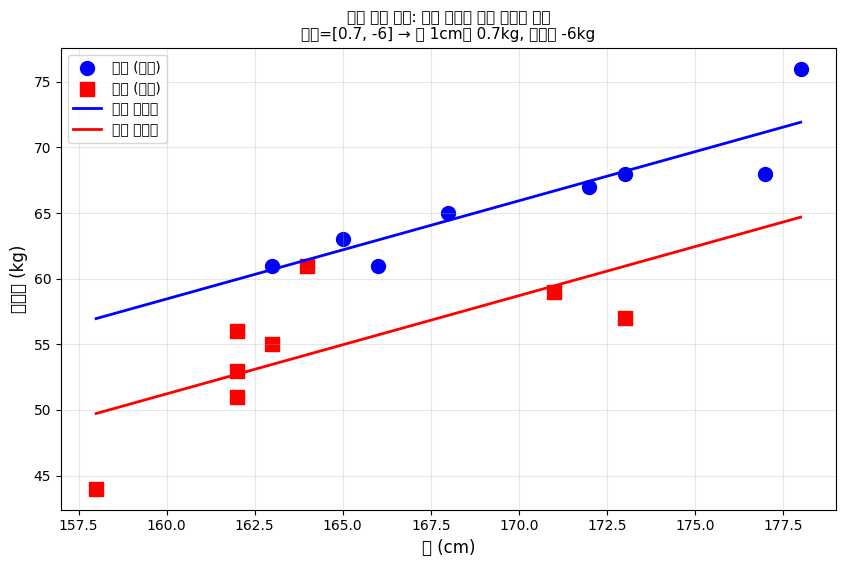

두 직선은 평행하며, 여자 선이 남자 선보다 약 6kg 아래에 위치합니다.


In [27]:
# 남녀 데이터 분리
X_male = [x[0] for i, x in enumerate(X) if x[1] == 0]
y_male = [y[i] for i, x in enumerate(X) if x[1] == 0]
X_female = [x[0] for i, x in enumerate(X) if x[1] == 1]
y_female = [y[i] for i, x in enumerate(X) if x[1] == 1]

# 회귀선 그리기
heights = np.linspace(158, 178, 100)
# 남자 회귀선 (성별=0)
weights_male = regr.predict([[h, 0] for h in heights])
# 여자 회귀선 (성별=1)
weights_female = regr.predict([[h, 1] for h in heights])

plt.figure(figsize=(10, 6))
plt.scatter(X_male, y_male, color='blue', s=100, marker='o', label='남자 (실제)')
plt.scatter(X_female, y_female, color='red', s=100, marker='s', label='여자 (실제)')
plt.plot(heights, weights_male, color='blue', linewidth=2, label='남자 회귀선')
plt.plot(heights, weights_female, color='red', linewidth=2, label='여자 회귀선')

plt.xlabel('키 (cm)', fontsize=12)
plt.ylabel('몸무게 (kg)', fontsize=12)
plt.title('다중 선형 회귀: 키와 성별에 따른 몸무게 예측\n계수=[0.7, -6] → 키 1cm당 0.7kg, 여자는 -6kg', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'두 직선은 평행하며, 여자 선이 남자 선보다 약 6kg 아래에 위치합니다.')

/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1052/273286058.py:49: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

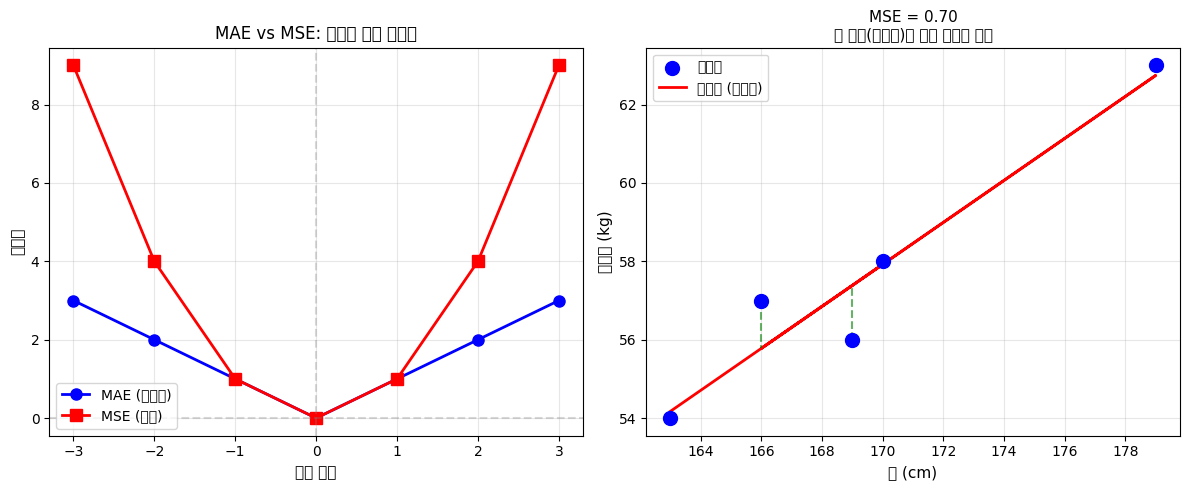

MSE는 큰 오차에 더 큰 페널티를 주어 이상치를 줄이는 방향으로 학습합니다.


In [28]:
# MSE vs MAE 비교
errors = np.array([-3, -2, -1, 0, 1, 2, 3])

# 절대값 오차 (MAE)
mae_penalty = np.abs(errors)
# 제곱 오차 (MSE)
mse_penalty = errors ** 2

plt.figure(figsize=(12, 5))

# 왼쪽: 패널티 비교
plt.subplot(1, 2, 1)
plt.plot(errors, mae_penalty, 'b-o', linewidth=2, markersize=8, label='MAE (절대값)')
plt.plot(errors, mse_penalty, 'r-s', linewidth=2, markersize=8, label='MSE (제곱)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.xlabel('오차 크기', fontsize=11)
plt.ylabel('패널티', fontsize=11)
plt.title('MAE vs MSE: 오차에 따른 패널티', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 오른쪽: 실제 데이터에 적용
plt.subplot(1, 2, 2)
# 이전 회귀 모델 사용 (키-몸무게)
from sklearn import linear_model
X_simple = [[163], [179], [166], [169], [170]]
y_simple = [54, 63, 57, 56, 58]
regr_temp = linear_model.LinearRegression()
regr_temp.fit(X_simple, y_simple)

y_pred = regr_temp.predict(X_simple)
errors_real = np.array(y_simple) - y_pred

plt.scatter(X_simple, y_simple, color='blue', s=100, label='실제값', zorder=3)
plt.plot(X_simple, y_pred, 'r-', linewidth=2, label='예측값 (회귀선)')

# 오차를 선으로 표시
for i in range(len(X_simple)):
    plt.plot([X_simple[i], X_simple[i]], [y_simple[i], y_pred[i]], 
             'g--', alpha=0.6, linewidth=1.5)
    
plt.xlabel('키 (cm)', fontsize=11)
plt.ylabel('몸무게 (kg)', fontsize=11)
plt.title(f'MSE = {np.mean(errors_real**2):.2f}\n큰 오차(초록선)에 제곱 패널티 부여', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'MSE는 큰 오차에 더 큰 페널티를 주어 이상치를 줄이는 방향으로 학습합니다.')

In [29]:
y = np.array([1.2, 2.4, 2.5, 4.6, 5.4])
y_hat = np.array([1, 2, 3, 4, 5])
diff = (y_hat - y) ** 2     # y_hat과 y의 차이값의 제곱
e_mse = diff.sum() / len(y)
print('평균 제곱 오차 = ', e_mse)

평균 제곱 오차 =  0.19399999999999995


In [31]:
from sklearn.metrics import mean_squared_error 
print('평균 제곱 오차 = ', mean_squared_error(y_hat, y))

평균 제곱 오차 =  0.19399999999999995


In [33]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])
regr_temp = linear_model.LinearRegression()

w, b = 0, 0    # w, b 초기값을 0으로 두자
learning_rate, epoch = 0.00001, 10000 # 학습률과 학습횟수(에폭)
n = len(X)  # 입력데이터 개수

for i in range(epoch):   # 학습 루프
    y_pred = w*X + b     # 현재 w, b를 이용한 작업 T
    error = y_pred - y   # 성능척도 P
    w = w - learning_rate * (error * X).sum() # 경험 E로 개선
    b = b - learning_rate * error.sum()

print(f'w = {w.round(2)}, b = {b.round(2)}')

w = 0.48, b = -0.15


In [34]:
from sklearn import linear_model
import numpy as np

X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])
regr = linear_model.LinearRegression()
X = X[:, np.newaxis] # 1차원 (5,)에서 2차원인 (5,1) 형태로 바꾼다
X
#regr.fit(X, y) # X, y 데이터를 사용하여 학습시키기

#print(f'w = {regr.coef_.round(2)}, b = {regr.intercept_.round(2)}')

array([[ 1. ],
       [ 4.5],
       [ 9. ],
       [10. ],
       [13. ]])

In [36]:
X[0,1]

IndexError: index 1 is out of bounds for axis 1 with size 1